## Example PCA Decision Boundary Methodology

### Imports

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

from matplotlib.pyplot import grid

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Decision Boundary Drawing Function 

In [2]:
def plot_pca_inverse_boundary(X_train_scaled, y_train, model, grid_points=1000, title_prefix="", use_proba=False):
    """
    Plots a decision boundary or probability gradient in 2D PCA space 
    for an N-dimensional trained model.
    """
    plt.figure(figsize=(9, 6))
    
    # Fit PCA on standardized training data
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_scaled)
    explained_variance = np.sum(pca.explained_variance_ratio_) * 100
    
    # Define grid boundaries
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    
    # Create grid within the subspace
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_points),
                         np.linspace(y_min, y_max, grid_points))
    
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    
    # Inverse transform to N-dimensional scaled space
    grid_nd_scaled = pca.inverse_transform(grid_2d)
    
    # Predict using the N-dimensional model
    if use_proba and hasattr(model, "predict_proba"):
        # Extract the probability of the positive class (class 1)
        Z = model.predict_proba(grid_nd_scaled)[:, 1]
        # Use a diverging colormap with smooth levels for probabilities
        cmap = plt.cm.RdBu
        levels = np.linspace(0, 1, 21)
    else:
        # Fallback to hard predictions
        Z = model.predict(grid_nd_scaled)
        cmap = plt.cm.RdYlBu
        levels = None
        
    Z = Z.reshape(xx.shape)
    
    # Plotting logic
    if use_proba:
        # Plot filled contours for probabilities with fixed 0 to 1 scale
        contour = plt.contourf(xx, yy, Z, levels=levels, alpha=0.8, cmap=cmap, vmin=0, vmax=1)
        plt.colorbar(contour, label="Probability of Class 1")
    else:
        # Plot standard discrete decision regions
        plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
        
    # Plot original training data
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, 
                s=30, edgecolor='k', cmap=plt.cm.RdYlBu)
    
    plt.title(f"{title_prefix}\nExplained Variance: {explained_variance:.1f}%")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()

In [3]:
n_features = 5
X_sim, y_sim = make_classification(n_samples=4000, n_features=n_features, 
                                   n_informative=5, n_redundant=0, 
                                   random_state=42, class_sep=1.5)

# Standardize the data
scaler_sim = StandardScaler()
X_sim_scaled = scaler_sim.fit_transform(X_sim)

rf_sim = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sim.fit(X_sim_scaled, y_sim)

svm_sim = SVC(kernel='rbf', probability=True, random_state=42)
svm_sim.fit(X_sim_scaled, y_sim)

# Cancer data
cancer_data = load_breast_cancer()
X_real, y_real = cancer_data.data, cancer_data.target
scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(X_real)

rf_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_real.fit(X_real_scaled, y_real)

svm_real = SVC(kernel='rbf', probability=True, random_state=42)
svm_real.fit(X_real_scaled, y_real)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


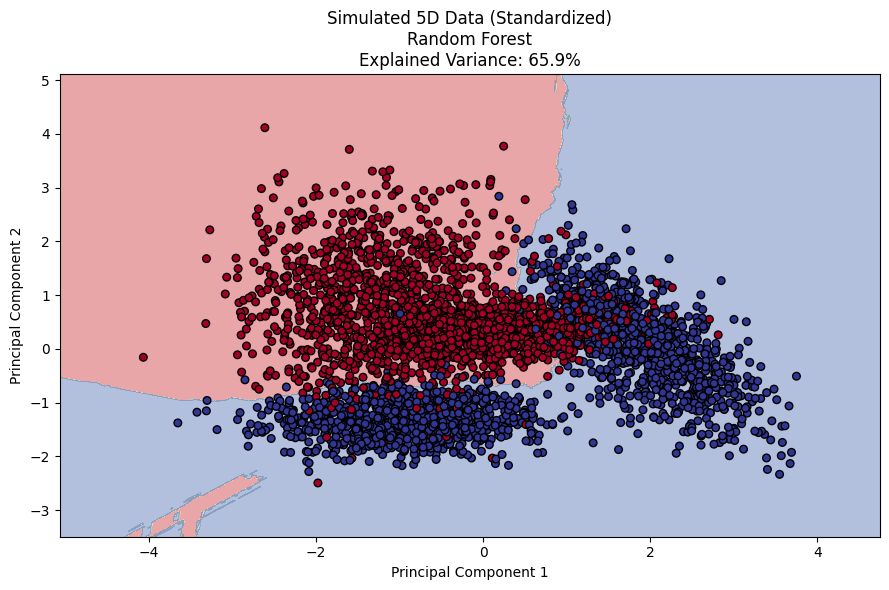

In [4]:
plot_pca_inverse_boundary(X_sim_scaled, y_sim, rf_sim, grid_points=1000,
                          title_prefix=f"Simulated {n_features}D Data (Standardized)\nRandom Forest")

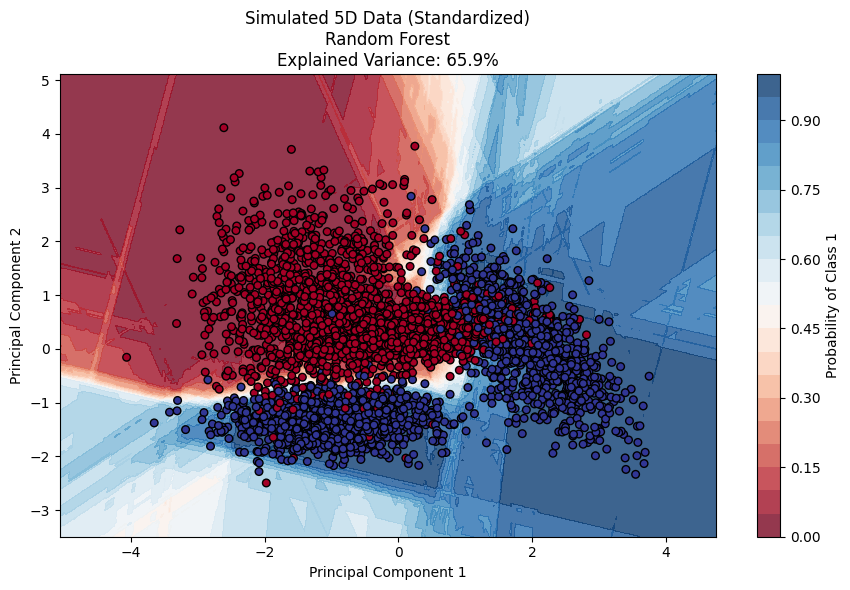

In [5]:
plot_pca_inverse_boundary(X_sim_scaled, y_sim, rf_sim, grid_points=1000, use_proba=True,
                          title_prefix=f"Simulated {n_features}D Data (Standardized)\nRandom Forest")

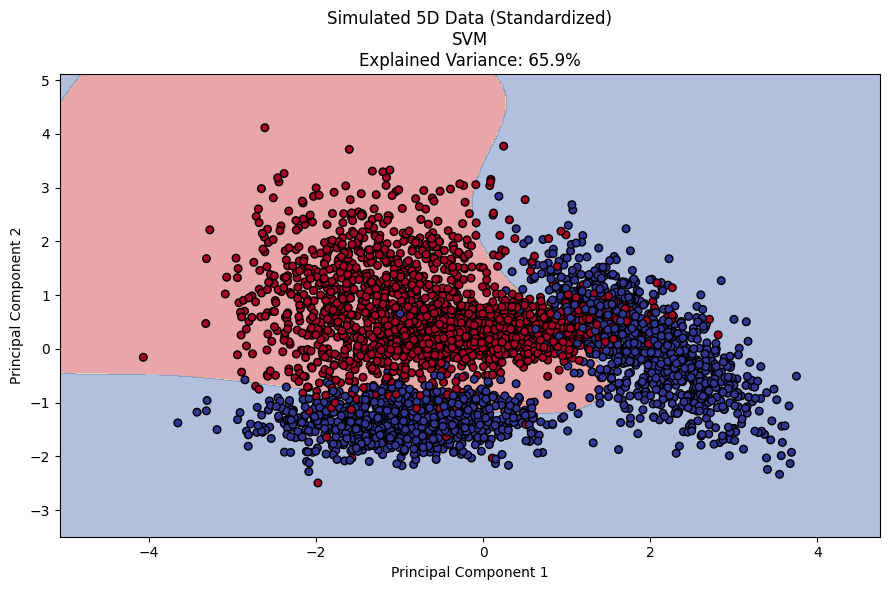

In [6]:
plot_pca_inverse_boundary(X_sim_scaled, y_sim, svm_sim, grid_points=1000,
                          title_prefix=f"Simulated {n_features}D Data (Standardized)\nSVM")

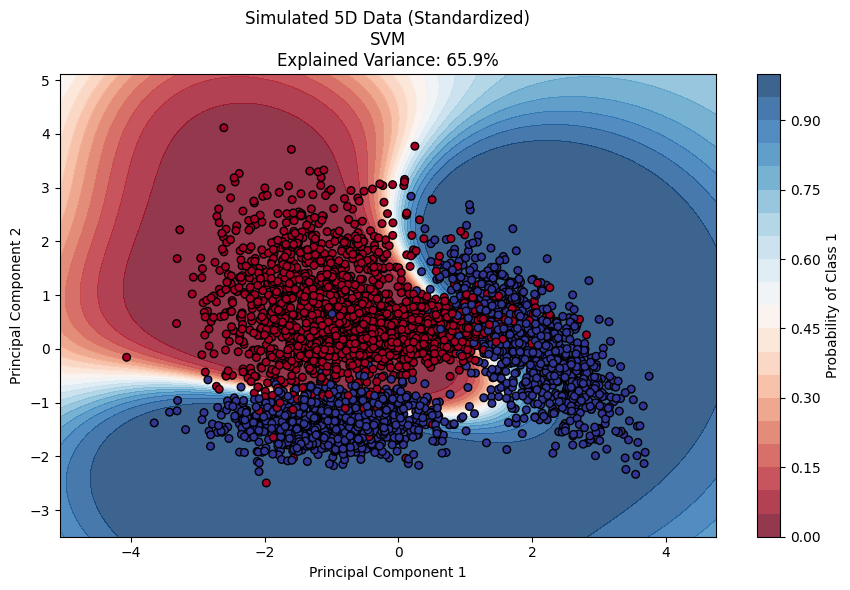

In [7]:
plot_pca_inverse_boundary(X_sim_scaled, y_sim, svm_sim, grid_points=1000, use_proba=True,
                          title_prefix=f"Simulated {n_features}D Data (Standardized)\nSVM")

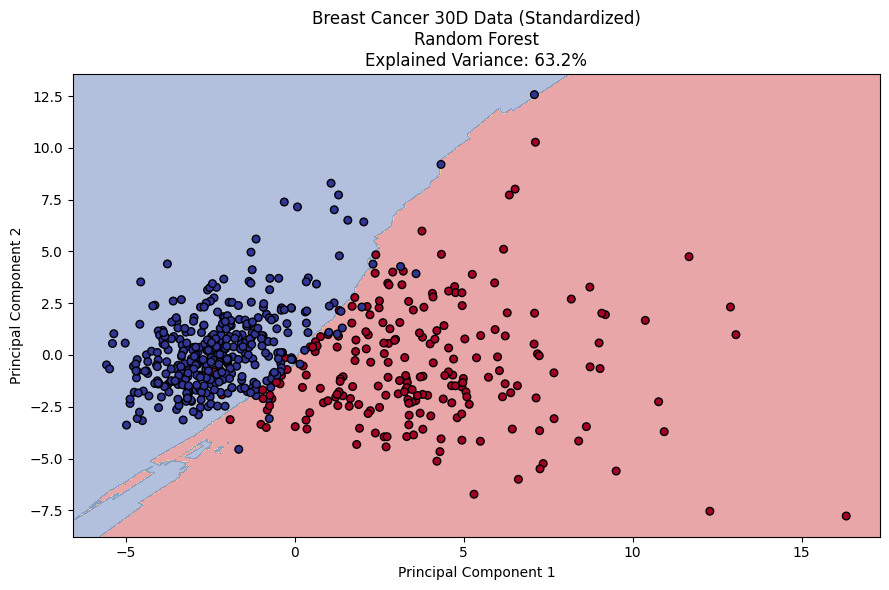

In [8]:
plot_pca_inverse_boundary(X_real_scaled, y_real, rf_real, grid_points=1000,
                          title_prefix="Breast Cancer 30D Data (Standardized)\nRandom Forest")

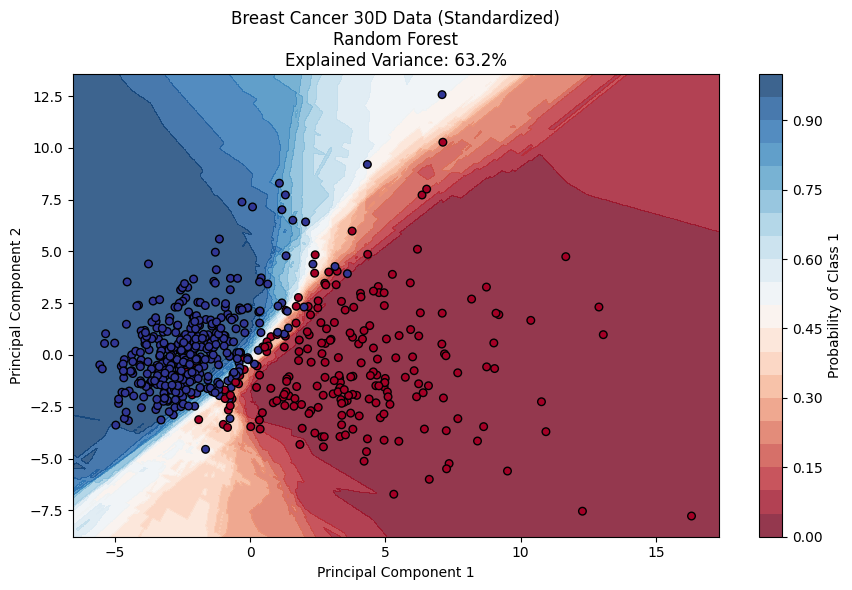

In [9]:
plot_pca_inverse_boundary(X_real_scaled, y_real, rf_real, grid_points=1000, use_proba=True,
                          title_prefix="Breast Cancer 30D Data (Standardized)\nRandom Forest")

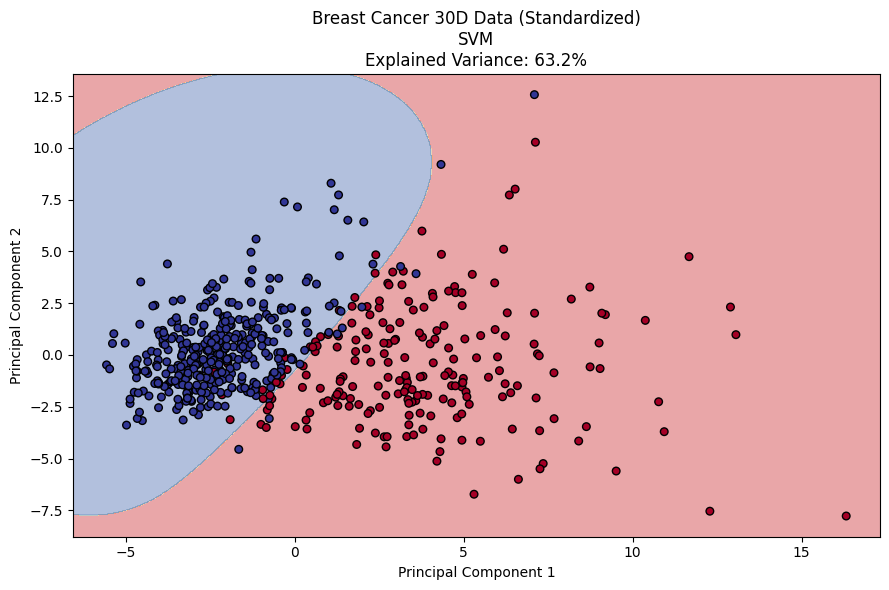

In [10]:
plot_pca_inverse_boundary(X_real_scaled, y_real, svm_real, grid_points=1000,
                          title_prefix="Breast Cancer 30D Data (Standardized)\nSVM")

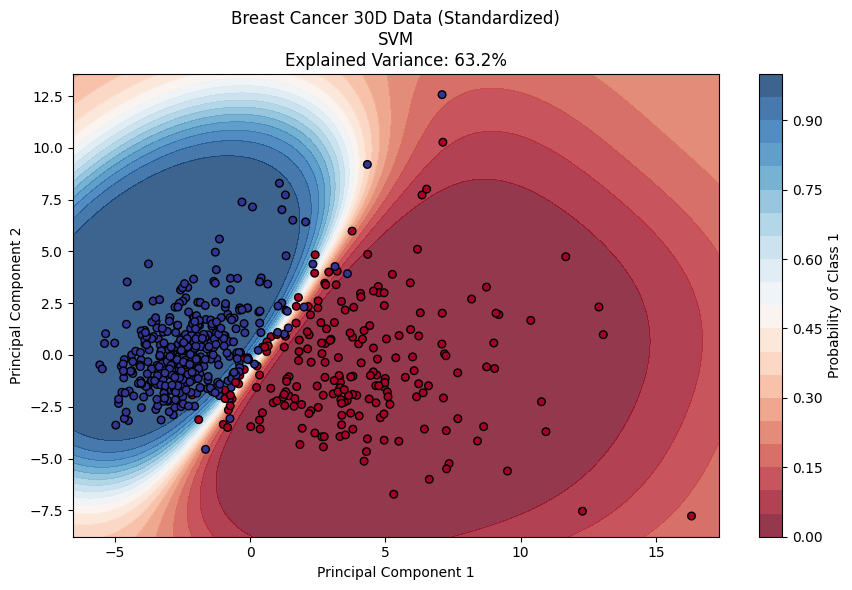

In [11]:
plot_pca_inverse_boundary(X_real_scaled, y_real, svm_real, grid_points=1000, use_proba=True,
                          title_prefix="Breast Cancer 30D Data (Standardized)\nSVM")